# 3.5 Escalonamento de Máquina (*Machine Scheduling*)

> Material de aula — Otimização / Programação Inteira Mista (MILO) e Programação Disjuntiva (GDP).
> Reprodução fiel do notebook **3.5 Machine Scheduling** do livro
> *Hands-On Mathematical Optimization with Python* (MO-book), com texto em português.

Neste notebook estudamos o problema de **escalonar um conjunto de tarefas (*jobs*) em uma única
máquina**, dados o instante de liberação (*release*), a duração (*duration*) e o prazo de
entrega (*due*) de cada tarefa.

O objetivo é encontrar uma **sequência** das tarefas na máquina que respeite os prazos. Quando
isso não é possível, busca-se o "menos ruim" dos escalonamentos, minimizando uma métrica de
desempenho escolhida.

Comparamos três caminhos:

1. **Regras empíricas / heurísticas** — FIFO, EDD e SPT;
2. **Modelo ótimo via programação disjuntiva (GDP)** em Pyomo;
3. **Modelo MILO equivalente** usando a técnica *big-M*.

Os dados do exemplo vêm do Capítulo 5 do livro de Guéret, Prins e Sevaux,
*Applications of Optimization with Xpress-MP* (Dash Optimization, 2000).

## Preâmbulo: instalação do Pyomo e de um solver

A célula a seguir define e verifica um `SOLVER` global para o notebook. Se executada no Google
Colab, ela instala o Pyomo e o solver **HiGHS**; caso contrário, assume que ambos já estão
instalados. O solver é acessado via módulo `appsi` e um teste confirma sua disponibilidade.

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install pyomo >/dev/null 2>/dev/null
    %pip install highspy >/dev/null 2>/dev/null

solver = "appsi_highs"

import pyomo.environ as pyo

SOLVER = pyo.SolverFactory(solver)

assert SOLVER.available(), f"Solver {solver} is not available."


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


## Descrição do problema

> "Qual tarefa deve ser feita a seguir?" é uma pergunta que aparece em inúmeros contextos: um
> estudante decidindo qual exercício fazer, um entregador roteirizando pacotes, um garçom
> atendendo mesas, um processador escalonando *threads* ou uma máquina em uma linha de montagem.

Existem regras empíricas conhecidas para responder a essa pergunta — como *first in, first out*,
*last in, first out* ou *shortest job first*. Aqui, em vez de aplicar apenas heurísticas,
**modelamos** o problema e o resolvemos com técnicas de otimização.

### Dados das tarefas

Os dados são dados como um `DataFrame` do Pandas, em que cada linha corresponde a uma tarefa,
com seu instante de liberação (`release`), duração (`duration`) e prazo (`due`).

In [3]:
jobs = pd.DataFrame(
    {
        "A": {"release": 2, "duration": 5, "due": 10},
        "B": {"release": 5, "duration": 6, "due": 21},
        "C": {"release": 4, "duration": 8, "due": 15},
        "D": {"release": 0, "duration": 4, "due": 10},
        "E": {"release": 0, "duration": 2, "due": 5},
        "F": {"release": 8, "duration": 3, "due": 15},
        "G": {"release": 9, "duration": 2, "due": 22},
    }
).T
display(jobs)


,release,duration,due
A,2,5,10
B,5,6,21
C,4,8,15
D,0,4,10
E,0,2,5
F,8,3,15
G,9,2,22


### Dados do escalonamento

Um escalonamento também é representado por um `DataFrame` indexado pelos nomes das tarefas. As
colunas indicam o início (`start`), o término (`finish`) e o atraso de cada tarefa (`past`, ou
seja, o quanto ela passou do prazo). A função abaixo constrói o escalonamento correspondente à
ordem em que as tarefas aparecem no `DataFrame` `jobs`.

In [4]:
def schedule_jobs(jobs, seq):
    schedule = pd.DataFrame(index=jobs.index)
    t = 0
    for job in seq:
        t = max(t, jobs.loc[job]["release"])
        schedule.loc[job, "start"] = t
        t += jobs.loc[job, "duration"]
        schedule.loc[job, "finish"] = t
        schedule.loc[job, "past"] = max(0, t - jobs.loc[job, "due"])

    return schedule


schedule = schedule_jobs(jobs, jobs.index)
schedule


,start,finish,past
A,2.0,7.0,0.0
B,7.0,13.0,0.0
C,13.0,21.0,6.0
D,21.0,25.0,15.0
E,25.0,27.0,22.0
F,27.0,30.0,15.0
G,30.0,32.0,10.0


### Gráfico de Gantt

Uma forma clássica de visualizar dados de escalonamento é o **gráfico de Gantt**. A próxima
célula define a função `gantt`, que plota o gráfico a partir dos dados das tarefas e do
escalonamento. A janela cinza indica o intervalo `release`–`due`; barras verdes indicam tarefas
concluídas no prazo e barras vermelhas, tarefas atrasadas.

Com a estratégia "ordem do dataframe", o atraso total é 68.0


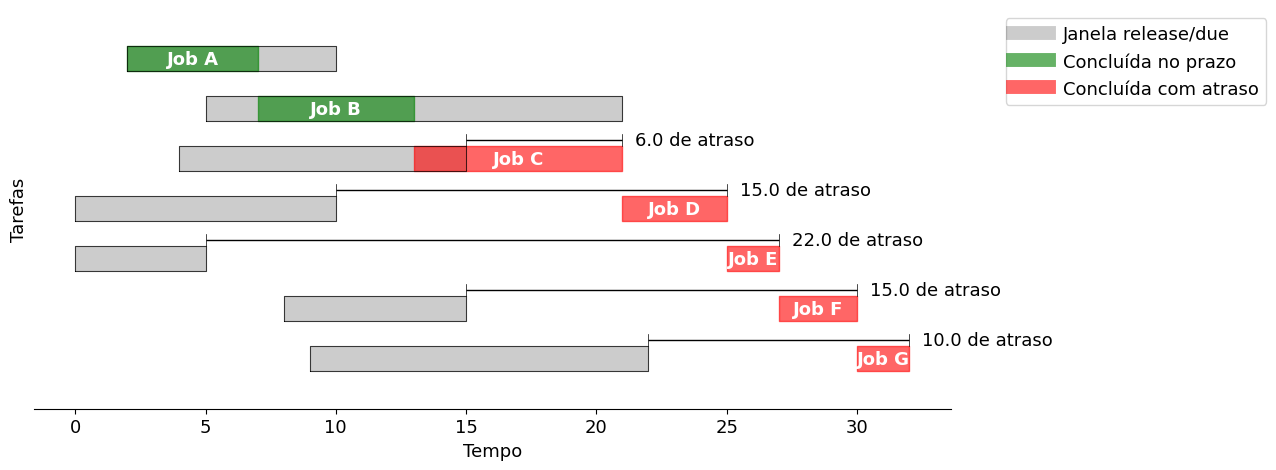

In [5]:
def gantt(jobs, schedule, title=""):
    w = 0.25  # largura da barra

    plt.rcParams.update({"font.size": 13})
    fig, ax = plt.subplots(1, 1, figsize=(13, 0.7 * len(jobs.index)))

    for k, job in enumerate(jobs.index):
        r = jobs.loc[job, "release"]
        d = jobs.loc[job, "due"]
        s = schedule.loc[job, "start"]
        f = schedule.loc[job, "finish"]

        # Janela release-due da tarefa
        ax.fill_between(
            [r, d], [-k - w, -k - w], [-k + w, -k + w], lw=1, color="k", alpha=0.2
        )
        ax.plot(
            [r, r, d, d, r], [-k - w, -k + w, -k + w, -k - w, -k - w], lw=0.5, color="k"
        )

        # Janela start-finish da tarefa
        color = "g" if f <= d else "r"
        ax.fill_between(
            [s, f], [-k - w, -k - w], [-k + w, -k + w], color=color, alpha=0.6
        )
        ax.text(
            (s + f) / 2.0,
            -k,
            "Job " + job,
            color="white",
            weight="bold",
            ha="center",
            va="center",
        )

        # Se atrasada
        if f > d:
            ax.plot([d] * 2, [-k + w, -k + 2 * w], lw=0.5, color="k")
            ax.plot([f] * 2, [-k + w, -k + 2 * w], lw=0.5, color="k")
            ax.plot([d, f], [-k + 1.5 * w] * 2, solid_capstyle="butt", lw=1, color="k")
            ax.text(
                f + 0.5,
                -k + 1.5 * w,
                f"{schedule.loc[job, 'past']:.1f} de atraso",
                va="center",
            )

    total_past_due = schedule["past"].sum()
    ax.set_ylim(-len(jobs.index), 1)
    print(f'Com a estratégia "{title}", o atraso total é {total_past_due:.1f}')
    ax.set_xlabel("Tempo")
    ax.set_ylabel("Tarefas")
    ax.set_yticks([])
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["top"].set_visible(False)

    custom_lines = [
        Line2D([0], [0], c="k", lw=10, alpha=0.2),
        Line2D([0], [0], c="g", lw=10, alpha=0.6),
        Line2D([0], [0], c="r", lw=10, alpha=0.6),
    ]
    ax.legend(
        custom_lines,
        ["Janela release/due", "Concluída no prazo", "Concluída com atraso"],
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
    )

    plt.tight_layout()
    plt.show()


gantt(jobs, schedule, "ordem do dataframe")


## Regras empíricas de escalonamento

Para comparar com o modelo de otimização, implementamos três regras empíricas bastante
conhecidas para escalonar tarefas em uma única máquina:

- **First in, first out (FIFO)** — primeiro a chegar, primeiro a ser atendido;
- **Earliest due date (EDD)** — prazo mais cedo primeiro;
- **Shortest processing time (SPT)** — menor tempo de processamento primeiro.

### First-in, first-out (FIFO)

Uma das regras mais comuns é executar as tarefas na ordem em que são liberadas para
processamento — ou seja, *primeiro a entrar, primeiro a sair*.

Com a estratégia "First in, First out", o atraso total é 31.0


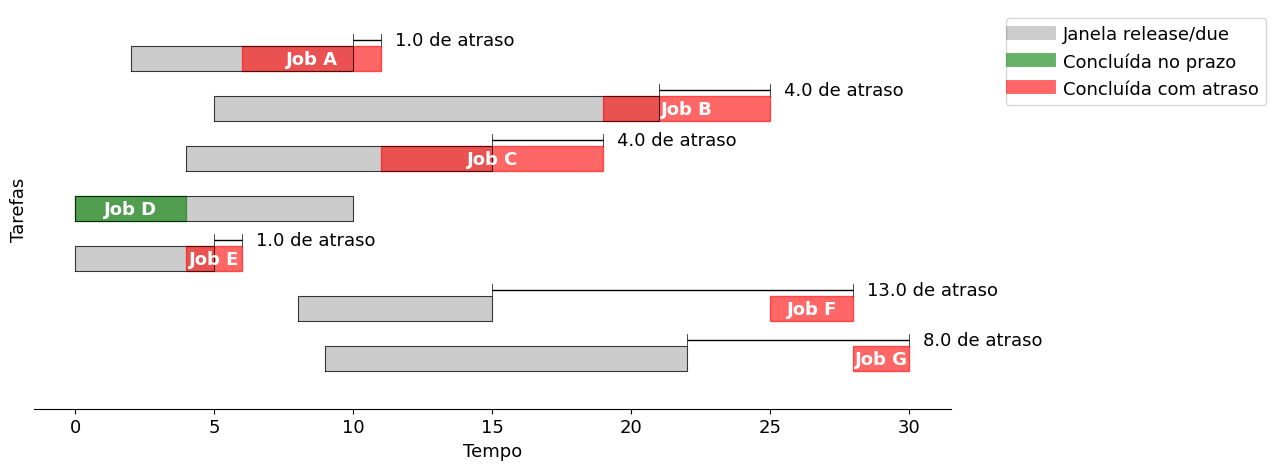

In [6]:
fifo = schedule_jobs(jobs, jobs.sort_values(by="release", kind="stable").index)
gantt(jobs, fifo, "First in, First out")


### Earliest due date (EDD)

Quando os prazos são conhecidos, uma regra comum é priorizar as tarefas pelo prazo de entrega.
Essa estratégia é familiar a qualquer estudante decidindo qual trabalho fazer primeiro.

Com a estratégia "Earliest due date", o atraso total é 27.0


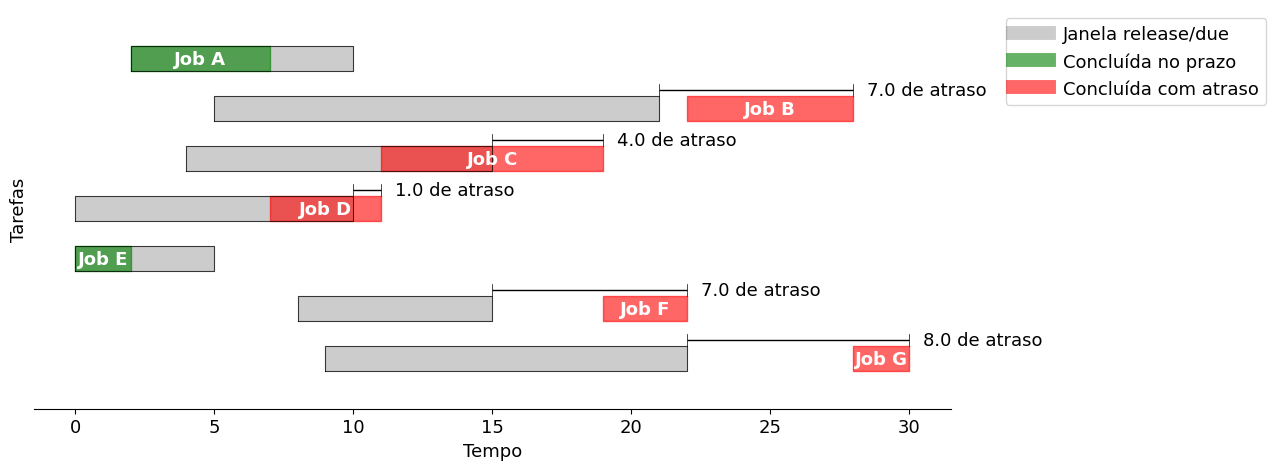

In [7]:
edd = schedule_jobs(jobs, jobs.sort_values(by="due", kind="stable").index)
gantt(jobs, edd, "Earliest due date")


### Shortest processing time (SPT)

Quando as durações são conhecidas, outra regra comum é priorizar as tarefas pelo (menor) tempo
de processamento restante.

Com a estratégia "Shortest Processing Time", o atraso total é 51.0


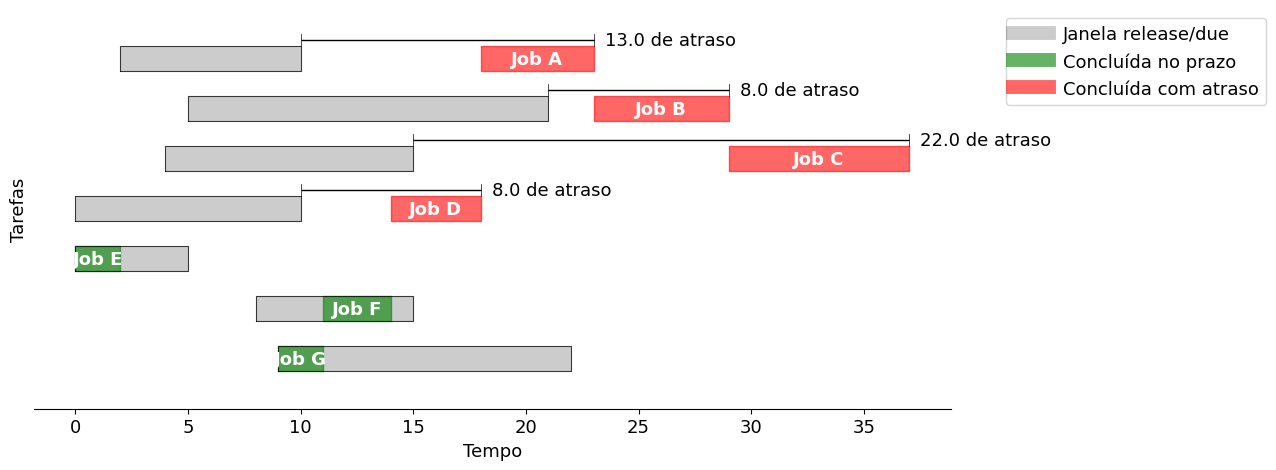

In [8]:
spt = schedule_jobs(jobs, jobs.sort_values(by="duration", kind="stable").index)
gantt(jobs, spt, "Shortest Processing Time")


## Escalonamento ótimo via programação disjuntiva

A modelagem começa pela definição dos dados do problema.

| Símbolo | Descrição |
| --- | --- |
| $\text{release}_j$ | quando a tarefa $j$ fica disponível |
| $\text{duration}_j$ | quanto tempo a tarefa $j$ leva |
| $\text{due}_j$ | quando a tarefa $j$ vence |

As variáveis de decisão essenciais são os instantes em que cada tarefa **inicia**. É conveniente
adicionar variáveis auxiliares para o instante de **término** e para o **atraso** de cada tarefa.

| Símbolo | Descrição |
| --- | --- |
| $\text{start}_j$ | quando a tarefa $j$ inicia |
| $\text{finish}_j$ | quando a tarefa $j$ termina |
| $\text{past}_j$ | quanto a tarefa $j$ está atrasada |

Dependendo da aplicação, vários objetivos são possíveis: número total de tarefas atrasadas, o
maior atraso, ou a soma de todos os atrasos. Aqui **minimizamos a soma dos atrasos**:

$$
\min \sum_j \text{past}_j
$$

As restrições descrevem as relações lógicas entre as variáveis. Uma tarefa não pode iniciar
antes de ser liberada:

$$
\text{start}_{j} \geq \text{release}_{j}
$$

Uma vez iniciada, a máquina processa a tarefa até o término. O término é comparado ao prazo, e
qualquer atraso é armazenado na variável $\text{past}_j$:

$$
\begin{aligned}
\text{finish}_j & = \text{start}_j + \text{duration}_j \\
\text{past}_{j} & \geq \text{finish}_j - \text{due}_{j} \\
\text{past}_{j} & \geq 0
\end{aligned}
$$

O último conjunto de restrições exige que **nenhum par de tarefas ocupe a máquina ao mesmo
tempo**. Para cada par único $(i, j)$ com $i < j$ (evitando contar o mesmo par duas vezes),
ou $i$ termina antes de $j$ iniciar, ou $j$ termina antes de $i$ iniciar. Isso é expresso pela
família de **disjunções**:

$$
\begin{bmatrix}
\text{finish}_i \leq \text{start}_j
\end{bmatrix}
\ \veebar \
\begin{bmatrix}
\text{finish}_j \leq \text{start}_i
\end{bmatrix}
\qquad \forall\, i < j
$$

Esse modelo se traduz diretamente para o Pyomo usando o componente `Disjunction`.

,start,finish,past
A,2.0,7.0,-0.0
B,14.0,20.0,0.0
C,22.0,30.0,15.0
D,7.0,11.0,1.0
E,0.0,2.0,-0.0
F,11.0,14.0,0.0
G,20.0,22.0,0.0


Com a estratégia "Minimizar atraso total", o atraso total é 16.0


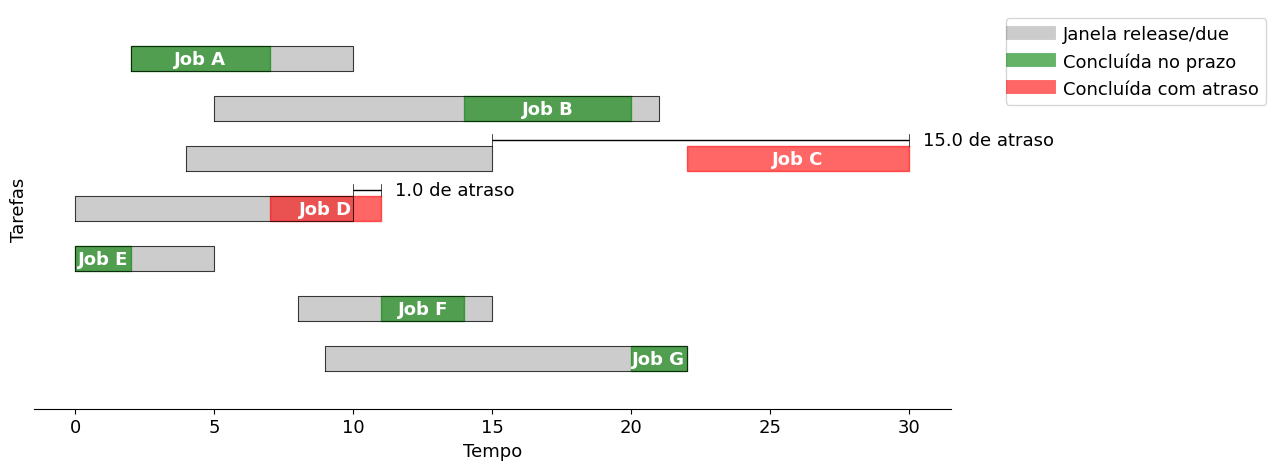

In [9]:
def machine_schedule(jobs):
    m = pyo.ConcreteModel("Job machine scheduling")

    # Conjunto de tarefas (índice do dataframe) e conjunto de pares
    # ordenados de tarefas distintas (i, j) com i < j
    m.JOBS = pyo.Set(initialize=jobs.index)
    m.PAIRS = pyo.Set(initialize=m.JOBS * m.JOBS, filter=lambda m, i, j: i < j)

    # Limite superior para o horizonte de tempo
    m.maxtime = pyo.Param(initialize=100)
    m.start = pyo.Var(m.JOBS, domain=pyo.NonNegativeReals, bounds=(0, m.maxtime))
    m.finish = pyo.Var(m.JOBS, domain=pyo.NonNegativeReals, bounds=(0, m.maxtime))
    m.past = pyo.Var(m.JOBS, domain=pyo.NonNegativeReals, bounds=(0, m.maxtime))

    @m.Constraint(m.JOBS)
    def job_release(m, job):
        return m.start[job] >= jobs.loc[job, "release"]

    @m.Constraint(m.JOBS)
    def job_duration(m, job):
        return m.finish[job] == m.start[job] + jobs.loc[job, "duration"]

    @m.Constraint(m.JOBS)
    def past_due_constraint(m, job):
        return m.past[job] >= m.finish[job] - jobs.loc[job, "due"]

    @m.Disjunction(m.PAIRS, xor=True)
    def machine_deconflict(m, job_a, job_b):
        return [m.finish[job_a] <= m.start[job_b], m.finish[job_b] <= m.start[job_a]]

    @m.Objective(sense=pyo.minimize)
    def minimize_past(m):
        return sum(m.past[job] for job in m.JOBS)

    return m


m = machine_schedule(jobs)
pyo.TransformationFactory("gdp.bigm").apply_to(m)
SOLVER.solve(m)

optimalschedule = pd.DataFrame(
    {
        "start": m.start.extract_values(),
        "finish": m.finish.extract_values(),
        "past": m.past.extract_values(),
    }
).round(2)

display(optimalschedule)
gantt(jobs, optimalschedule, "Minimizar atraso total")


A solução obtida pela otimização **supera** qualquer uma das regras empíricas. Ainda assim,
heurísticas continuam essenciais para problemas de escalonamento de grande porte.

### Modelo MILO equivalente (*big-M*)

Para comparação, implementamos também um MILO padrão usando a técnica **big-M**. A ideia é
introduzir uma variável binária $z_{ij} \in \{0,1\}$ para cada disjunção acima:

$$
\begin{aligned}
\text{finish}_i & \leq \text{start}_j + M\, z_{ij} \\
\text{finish}_j & \leq \text{start}_i + M\, (1 - z_{ij})
\end{aligned}
$$

Isso cria um modelo MILO **equivalente**, que leva à mesma solução, mas com muito mais variáveis
— em geral, mais lento de resolver.

,start,finish,past
A,2.0,7.0,0.0
B,14.0,20.0,0.0
C,22.0,30.0,15.0
D,7.0,11.0,1.0
E,0.0,2.0,-0.0
F,11.0,14.0,-0.0
G,20.0,22.0,0.0


Com a estratégia "Minimizar atraso total", o atraso total é 16.0


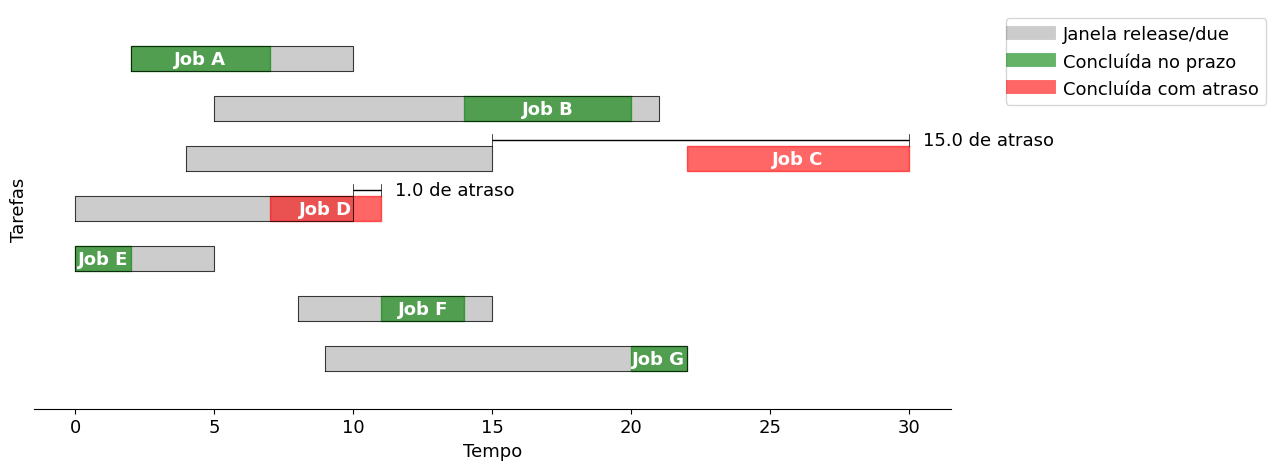

In [10]:
def machine_scheduleMILO(jobs):
    m = pyo.ConcreteModel("Job machine scheduling using MILO formulation")

    m.JOBS = pyo.Set(initialize=jobs.index)
    m.PAIRS = pyo.Set(initialize=m.JOBS * m.JOBS, filter=lambda m, i, j: i < j)

    m.maxtime = pyo.Param(initialize=100)
    m.start = pyo.Var(m.JOBS, domain=pyo.NonNegativeReals, bounds=(0, m.maxtime))
    m.finish = pyo.Var(m.JOBS, domain=pyo.NonNegativeReals, bounds=(0, m.maxtime))
    m.past = pyo.Var(m.JOBS, domain=pyo.NonNegativeReals, bounds=(0, m.maxtime))

    # Variáveis binárias auxiliares para linearizar a disjunção (big-M)
    m.z = pyo.Var(m.PAIRS, domain=pyo.Binary)
    m.bigM = pyo.Param(initialize=10000)

    @m.Constraint(m.JOBS)
    def job_release(m, job):
        return m.start[job] >= jobs.loc[job, "release"]

    @m.Constraint(m.JOBS)
    def job_duration(m, job):
        return m.finish[job] == m.start[job] + jobs.loc[job, "duration"]

    @m.Constraint(m.JOBS)
    def past_due_constraint(m, job):
        return m.past[job] >= m.finish[job] - jobs.loc[job, "due"]

    @m.Constraint(m.PAIRS)
    def machine_deconflict_a(m, job_a, job_b):
        return m.finish[job_a] <= m.start[job_b] + m.bigM * (1 - m.z[job_a, job_b])

    @m.Constraint(m.PAIRS)
    def machine_deconflict_b(m, job_a, job_b):
        return m.finish[job_b] <= m.start[job_a] + m.bigM * m.z[job_a, job_b]

    @m.Objective(sense=pyo.minimize)
    def minimize_past(m):
        return sum(m.past[job] for job in m.JOBS)

    SOLVER.solve(m)

    return m


m = machine_scheduleMILO(jobs)

optimalschedule_MILO = pd.DataFrame(
    {
        "start": m.start.extract_values(),
        "finish": m.finish.extract_values(),
        "past": m.past.extract_values(),
    }
).round(2)

display(optimalschedule_MILO)
gantt(jobs, optimalschedule_MILO, "Minimizar atraso total")


## Síntese

| Estratégia | Atraso total |
| --- | --- |
| Ordem do dataframe | 68 |
| SPT (menor processamento) | 51 |
| FIFO (primeiro a chegar) | 31 |
| EDD (prazo mais cedo) | 27 |
| **Ótimo (GDP / MILO)** | **16** |

Observações para a aula:

- As regras empíricas são rápidas e simples, mas **subótimas** — aqui a melhor delas (EDD) ainda
  fica 11 unidades acima do ótimo.
- A formulação **GDP** é mais legível e deixa a lógica disjuntiva explícita; o Pyomo a converte
  para um MILO via transformação (`gdp.bigm` ou `gdp.hull`).
- A formulação **MILO big-M** é equivalente, mas a qualidade da relaxação linear depende do valor
  de $M$: valores muito grandes enfraquecem a relaxação e tendem a tornar a resolução mais lenta.
- Para instâncias grandes, heurísticas (e meta-heurísticas) voltam a ser indispensáveis como
  ponto de partida ou como solução de compromisso.